<a href="https://colab.research.google.com/github/YoungJang-KR/semiconductor-fault-detection/blob/main/01_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

path_train = '/content/drive/MyDrive/phm18/train/01_M01_DC_train.csv'

df_train = pd.read_csv(path_train)
print("행, 렬:", df_train.shape)
print("열 항목:", df_train.columns.tolist())

행, 렬: (3124704, 24)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION']


In [9]:
path_ttf = '/content/drive/MyDrive/phm18/train_ttf/01_M01_DC_train.csv'
df_ttf = pd.read_csv(path_ttf)

print("행, 렬:", df_ttf.shape)
print("열 항목:", df_ttf.columns.tolist())

행, 렬: (3124704, 4)
열 항목: ['time', 'TTF_FlowCool Pressure Dropped Below Limit', 'TTF_Flowcool Pressure Too High Check Flowcool Pump', 'TTF_Flowcool leak']


In [10]:
path_fault = '/content/drive/MyDrive/phm18/train_faults/01_M01_train_fault_data.csv'

df_fault = pd.read_csv(path_fault)
print("행, 렬:", df_fault.shape)
print("열 항목:", df_fault.columns.tolist())

행, 렬: (19, 3)
열 항목: ['time', 'fault_name', 'Tool']


In [12]:
# 표 분석을 위해 df_train과 df_ttf를 시간 기준으로 merge한다.
df = df_train.merge(df_ttf, on='time')
# merge가 잘 되었나 확인

print("행, 렬:", df.shape)

행, 렬: (3135742, 27)


In [14]:
# train_ttf의 열 항목 이름이 너무 긺으로 축약해주기
df = df.rename( columns={
    'TTF_FlowCool Pressure Dropped Below Limit': 'TTF_pressure_drop',
    'TTF_Flowcool Pressure Too High Check Flowcool Pump': 'TTF_pressure_high',
    'TTF_Flowcool leak': 'TTF_leak'
})
# 확인해보기
print("열 항목:", df.columns.tolist())


열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


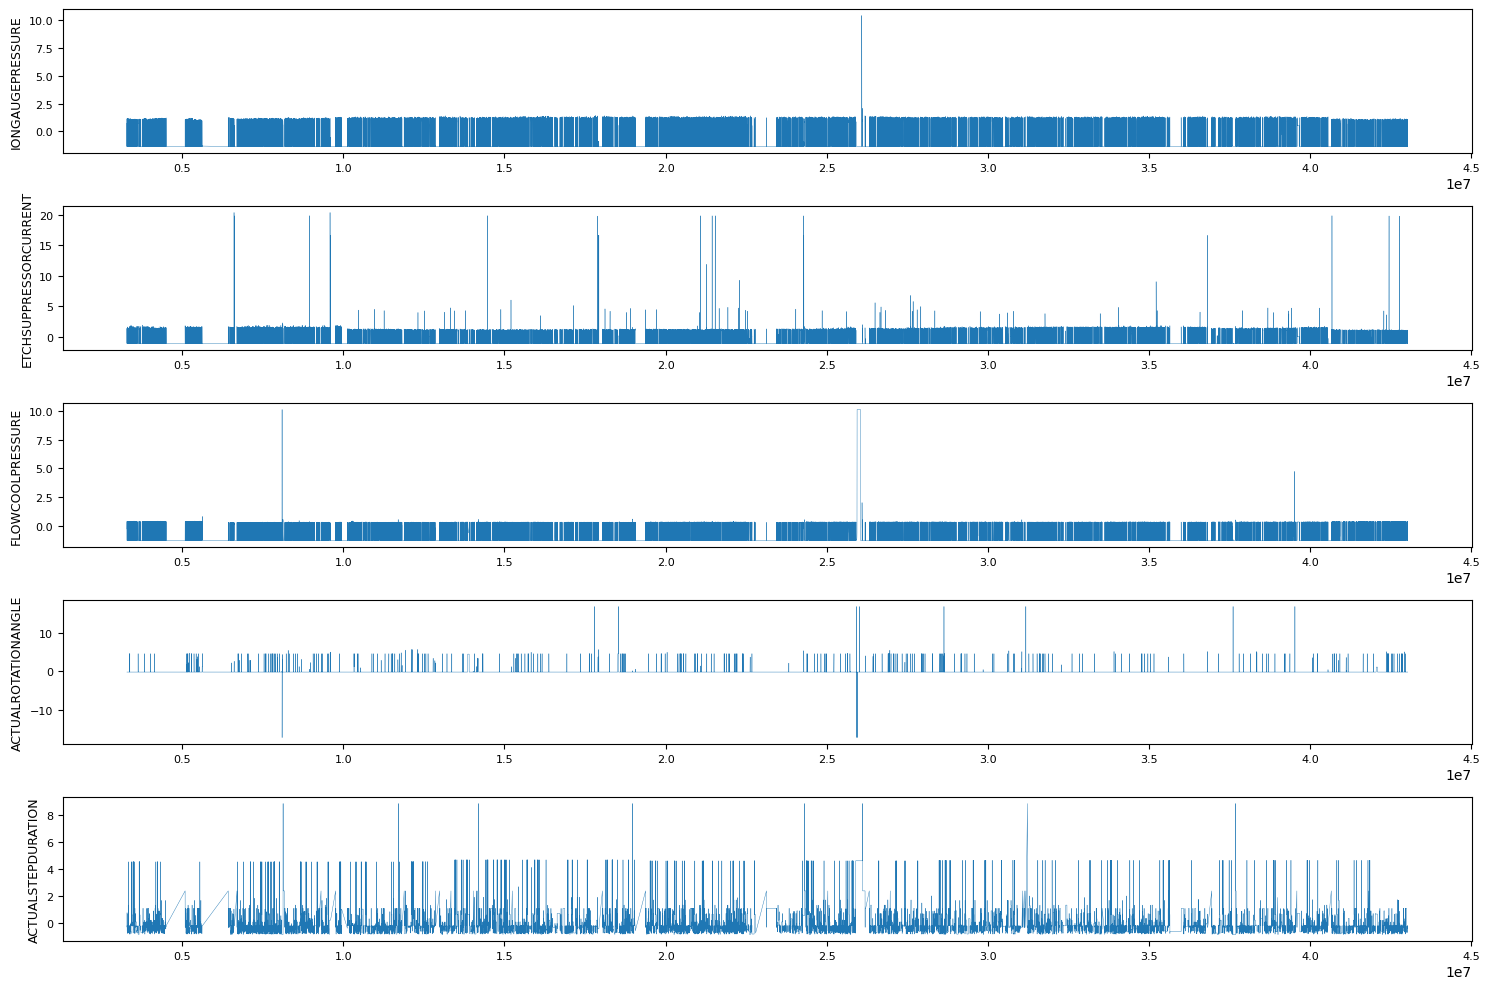

In [15]:
import matplotlib.pyplot as plt

sensor_cols = [ 'IONGAUGEPRESSURE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLPRESSURE',
               'ACTUALROTATIONANGLE', 'ACTUALSTEPDURATION']

# 전체적인 도화지 그리기
fig, axes = plt.subplots( len(sensor_cols), 1, figsize=(15, len(sensor_cols)*2) )

for i, col in enumerate(sensor_cols):
  axes[i].plot( df['time'], df[col], linewidth=0.3 )
  axes[i].set_ylabel(col, fontsize=9)
  axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

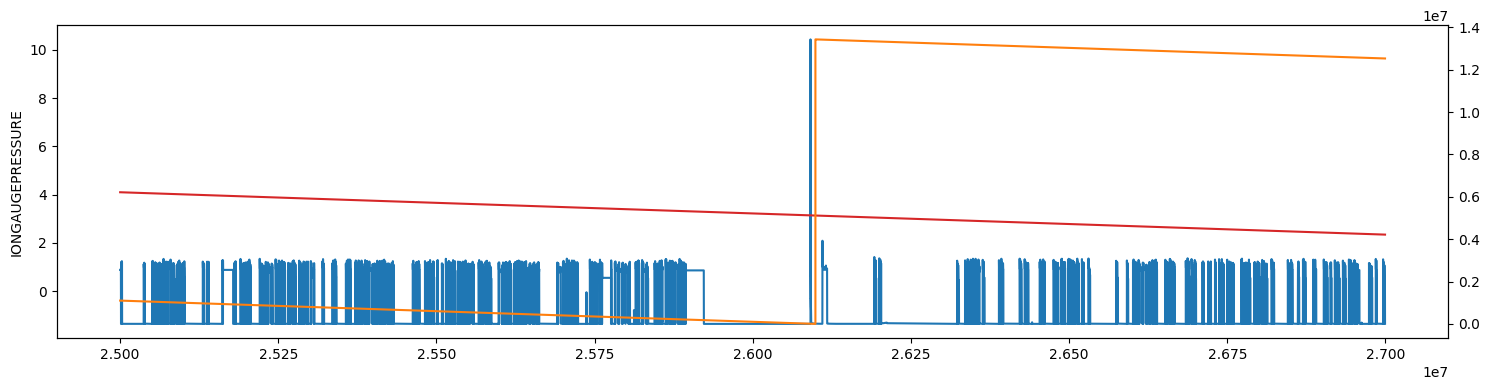

In [17]:
window = df[ (df['time'] > 2.5e7) & (df['time'] < 2.7e7) ]

# 도화지 그리기
fig, ax1 = plt.subplots(figsize=(15, 4))
ax1.plot( window['time'], window['IONGAUGEPRESSURE'], color='tab:blue')
ax1.set_ylabel('IONGAUGEPRESSURE')

ax2 = ax1.twinx()
ax2.plot( window['time'], window['TTF_pressure_drop'], color='tab:red')
ax2.plot( window['time'], window['TTF_pressure_high'], color='tab:orange')
ax2.plot( window['time'], window['TTF_leak'], color='tab:green')

plt.tight_layout()
plt.show()

6.16